# Lab 2 Arduino DAQ
Jemila Momoh & Caroline Mahoney

In [1]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sounddevice as sd

from scipy.signal import welch 

%matplotlib widget 

import mplcursors 

# Arduino Data
Start by uploading the Arduino_DAQ script to the arduino with a sampling frequency of 4 ms

In [2]:
# Import the Data
data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/lab2data.csv")
data.head() # display the first few rows of the dataframe to check that it loaded correctly

,Time (ms),Sensor 0 (raw),Sensor 1 (raw),Sensor 2 (raw)
0,4,507,554,170
1,8,178,299,75
2,12,46,139,21
3,16,1,56,0
4,20,0,17,0


# Scale & Plot the Data
Convert the data from the Arduino’s raw output to volts then plot it

Vcc = power supply = 5.13 V (measured) 

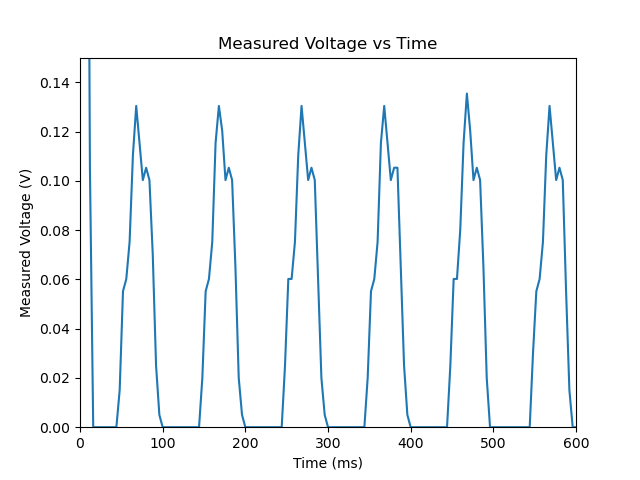

In [3]:
data['Sensor 2 (measured V)'] = data['Sensor 2 (raw)']* (5.13 / 1023.0)  # Create a new column in the dataframe based on the existing data column 

plt.figure()  # Create a new figure
sns.lineplot(x="Time (ms)", y="Sensor 2 (measured V)", data=data)
plt.title("Measured Voltage vs Time")
plt.xlabel("Time (ms)")
plt.ylabel("Measured Voltage (V)")
plt.xlim(0, 600)  # Set x-axis limits
plt.ylim(0, 0.15) # Set y-axis limits

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

plt.show()

# Offset the Signal
The data isn't displaying as expected because the arduino can't capture negative data. offset the signal to see the full sine wave

Import and scale the data the same as above

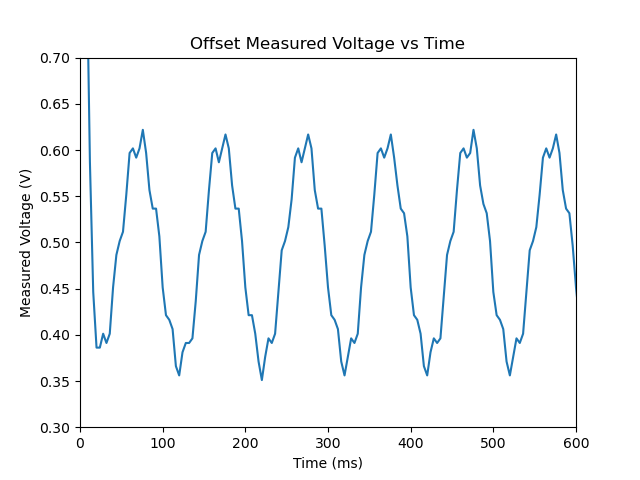

In [4]:
offset_data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/offset_lab2data.csv") # Import the new offset data
offset_data['Sensor 2 (measured V)'] = offset_data['Sensor 2 (raw)']* (5.13 / 1023.0)  # Scale the data 
# Plot the Offset Data
plt.figure()  # Create a new figure
sns.lineplot(x="Time (ms)", y="Sensor 2 (measured V)", data=offset_data)
plt.title("Offset Measured Voltage vs Time")
plt.xlabel("Time (ms)")
plt.ylabel("Measured Voltage (V)")
plt.xlim(0, 600)  # Set x-axis limits
plt.ylim(0.3, 0.7) # Set y-axis limits

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

plt.show()

# Demonstrating Aliasing
Capturing a sine wave with a frequency above the Nyquist frequency to demonstrate aliasing

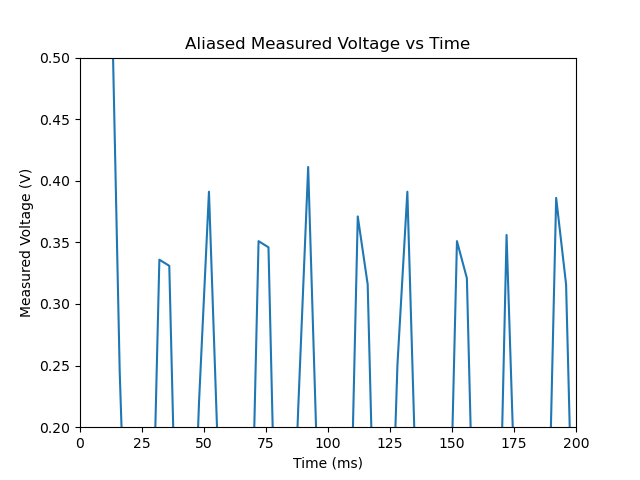

In [5]:
aliased_data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/aliased_lab2data.csv") # Import the aliased data
aliased_data['Sensor 2 (measured V)'] = aliased_data['Sensor 2 (raw)']* (5.13 / 1023.0)  # Scale the data

plt.figure()  # Create a new figure
sns.lineplot(x="Time (ms)", y="Sensor 2 (measured V)", data=aliased_data)
plt.title("Aliased Measured Voltage vs Time")
plt.xlabel("Time (ms)")
plt.ylabel("Measured Voltage (V)")
plt.xlim(0, 200)  # Set x-axis limits
plt.ylim(0.2, 0.5) # Set y-axis limits

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

plt.show()

# Demonstrating Bit Noise

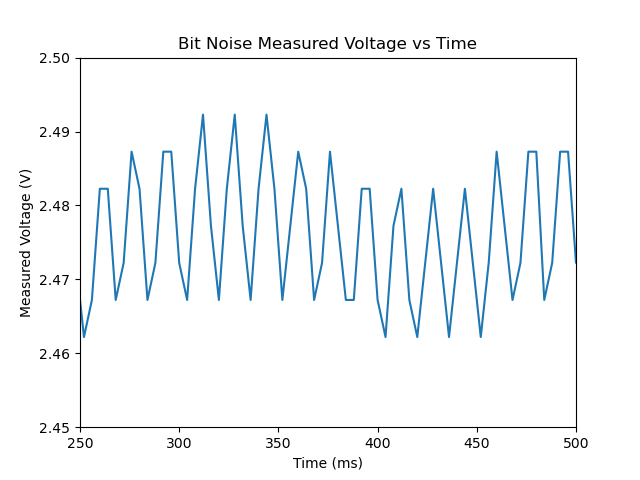

In [6]:
bn_data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/bit_lab2data.csv") # Import the bit noise data
bn_data['Sensor 2 (measured V)'] = bn_data['Sensor 2 (raw)']* (5.13 / 1023.0)  # Scale the data 

plt.figure()  # Create a new figure
sns.lineplot(x="Time (ms)", y="Sensor 2 (measured V)", data=bn_data)
plt.title("Bit Noise Measured Voltage vs Time")
plt.xlabel("Time (ms)")
plt.ylabel("Measured Voltage (V)")
plt.xlim(250, 500)  # Set x-axis limits
plt.ylim(2.45, 2.5) # Set y-axis limits

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

plt.show()

# Post Processing
Generating Power Spectral Density (PSD) plots for two cases

# Final Signal PSD Plot

Using the original data (data) 

/opt/anaconda3/lib/python3.12/site-packages/scipy/signal/_spectral_py.py:600: UserWarning: nperseg = 512 is greater than input length  = 500, using nperseg = 500
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


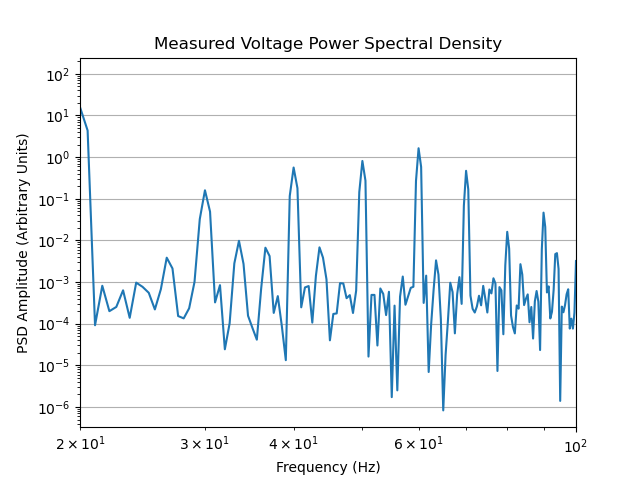

In [7]:
# Calculate sampling frequency from time interval
time_interval_ms = data['Time (ms)'].iloc[1] - data['Time (ms)'].iloc[0]  # Time difference between samples in ms
fs_data = 1000 / time_interval_ms  # Convert to Hz (1000 to convert from ms to s)

# Define input parameters for Welch's method
signal_segment_size = 512 # Number of samples per segment (must be less than or equal to the length of the data)
signal_overlap_pct = 60
signal_overlap_size = int(signal_segment_size * signal_overlap_pct / 100)

# Compute Power Spectral Density using Welch's method
f_signal, pxx_signal = welch(data['Sensor 2 (raw)'], fs=fs_data, window="hann", nperseg=signal_segment_size, noverlap=signal_overlap_size)

plt.figure() # Create a new figure
sns.lineplot(x=f_signal, y=pxx_signal)
plt.xscale('log')  # Logarithmic scale for frequency axis
plt.yscale('log')  # Logarithmic scale for power spectral density
plt.xlim([20, 100])  # Limit x-axis to typical audio frequency range
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD Amplitude (Arbitrary Units)')
plt.title('Measured Voltage Power Spectral Density')
plt.grid(True)
mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
plt.show()

# Aliasing PSD Plot

PSD plot of the aliased data

/opt/anaconda3/lib/python3.12/site-packages/scipy/signal/_spectral_py.py:600: UserWarning: nperseg = 512 is greater than input length  = 500, using nperseg = 500
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


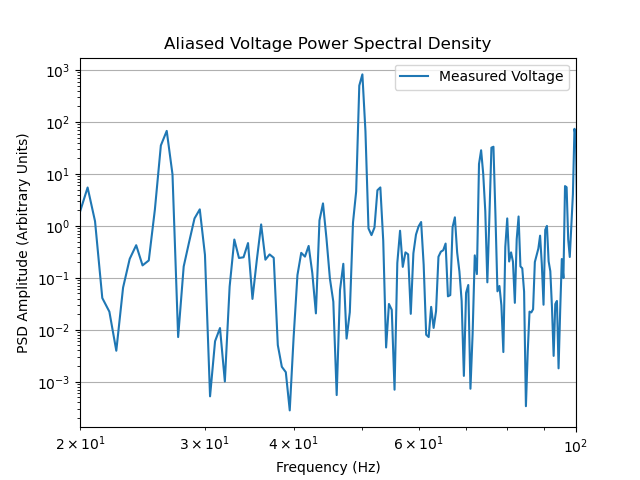

In [8]:
# Calculate sampling frequency from time interval
time_interval_ms = aliased_data['Time (ms)'].iloc[1] - aliased_data['Time (ms)'].iloc[0]  # Time difference between samples in ms
fs_data = 1000 / time_interval_ms  # Convert to Hz (1000 to convert from ms to s)

# Define input parameters for Welch's method
signal_segment_size = 512 # Number of samples per segment (must be less than or equal to the length of the data)
signal_overlap_pct = 60
signal_overlap_size = int(signal_segment_size * signal_overlap_pct / 100)

# Compute Power Spectral Density using Welch's method
f_signal, pxx_signal = welch(aliased_data['Sensor 2 (raw)'], fs=fs_data, window="hann", nperseg=signal_segment_size, noverlap=signal_overlap_size)

plt.figure() # Create a new figure
sns.lineplot(x=f_signal, y=pxx_signal, label='Measured Voltage')
plt.xscale('log')  # Logarithmic scale for frequency axis
plt.yscale('log')  # Logarithmic scale for power spectral density
plt.xlim([20, 100])  # Limit x-axis to typical audio frequency range
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD Amplitude (Arbitrary Units)')
plt.title('Aliased Voltage Power Spectral Density')
plt.grid(True)
mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
plt.show()